# 01 — Análisis Exploratorio de Datos (EDA)
## Proyecto: Predicción de Abandono Estudiantil — EAFIT 2026-1
**Integrante:** Helen Sanabria (EDA & Preprocesamiento)  
**Dataset:** Student Dropout Prediction (UCI/Kaggle)  
**Objetivo:** Explorar el dataset, identificar patrones clave de deserción y documentar las decisiones de preprocesamiento que guiarán al modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='muted')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


In [2]:
# CORRECCIÓN: separador es coma, no punto y coma
df = pd.read_csv('../data/raw/dataset.csv', sep=',')

print(f'Shape del dataset: {df.shape}')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print(f'\nColumnas: {df.columns.tolist()}')

# Verificar que Target existe
if 'Target' in df.columns:
    print('\n✓ Columna Target encontrada')
    print(df['Target'].value_counts())
else:
    print('\n⚠️ Target no encontrada — columnas disponibles:')
    print(df.columns.tolist())

df.head()

Shape del dataset: (4424, 35)
Filas: 4424 | Columnas: 35

Columnas: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target'

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [4]:
df.describe().round(2)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,...,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,6.89,1.73,9.90,0.89,2.53,1.25,12.32,16.46,7.32,...,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,5.30,1.31,4.33,0.31,3.96,1.75,9.03,11.04,4.00,...,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,6.00,1.00,1.00,1.00,2.00,3.00,5.00,...,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,8.00,1.00,10.00,1.00,1.00,1.00,13.00,14.00,6.00,...,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,12.00,2.00,13.00,1.00,1.00,1.00,22.00,27.00,10.00,...,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,18.00,9.00,17.00,1.00,17.00,21.00,29.00,34.00,32.00,...,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


In [5]:
null_df = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Nulos', ascending=False)

print('=' * 45)
print('ANÁLISIS DE VALORES NULOS')
print('=' * 45)
nulos_existentes = null_df[null_df['Nulos'] > 0]
if len(nulos_existentes) == 0:
    print('✓ El dataset NO tiene valores nulos.')
    print('  Estrategia: No se requiere imputación.')
else:
    print(nulos_existentes)

print(f'\nTotal valores nulos: {df.isnull().sum().sum()}')

ANÁLISIS DE VALORES NULOS
✓ El dataset NO tiene valores nulos.
  Estrategia: No se requiere imputación.

Total valores nulos: 0


**Decisión documentada:**  
El dataset no presenta ningún valor nulo en las 36 variables.  
Esto elimina la necesidad de imputación o eliminación de registros.  
La integridad de los datos es completa, lo que permite proceder directamente al análisis de outliers y correlaciones sin pérdida de información.

## Visualización 1 — Distribución de la Variable Objetivo
Esta es la visualización más crítica: muestra cuántos estudiantes desertan, se gradúan o permanecen matriculados. El desbalance de clases aquí determina la estrategia de modelado del Integrante 2.

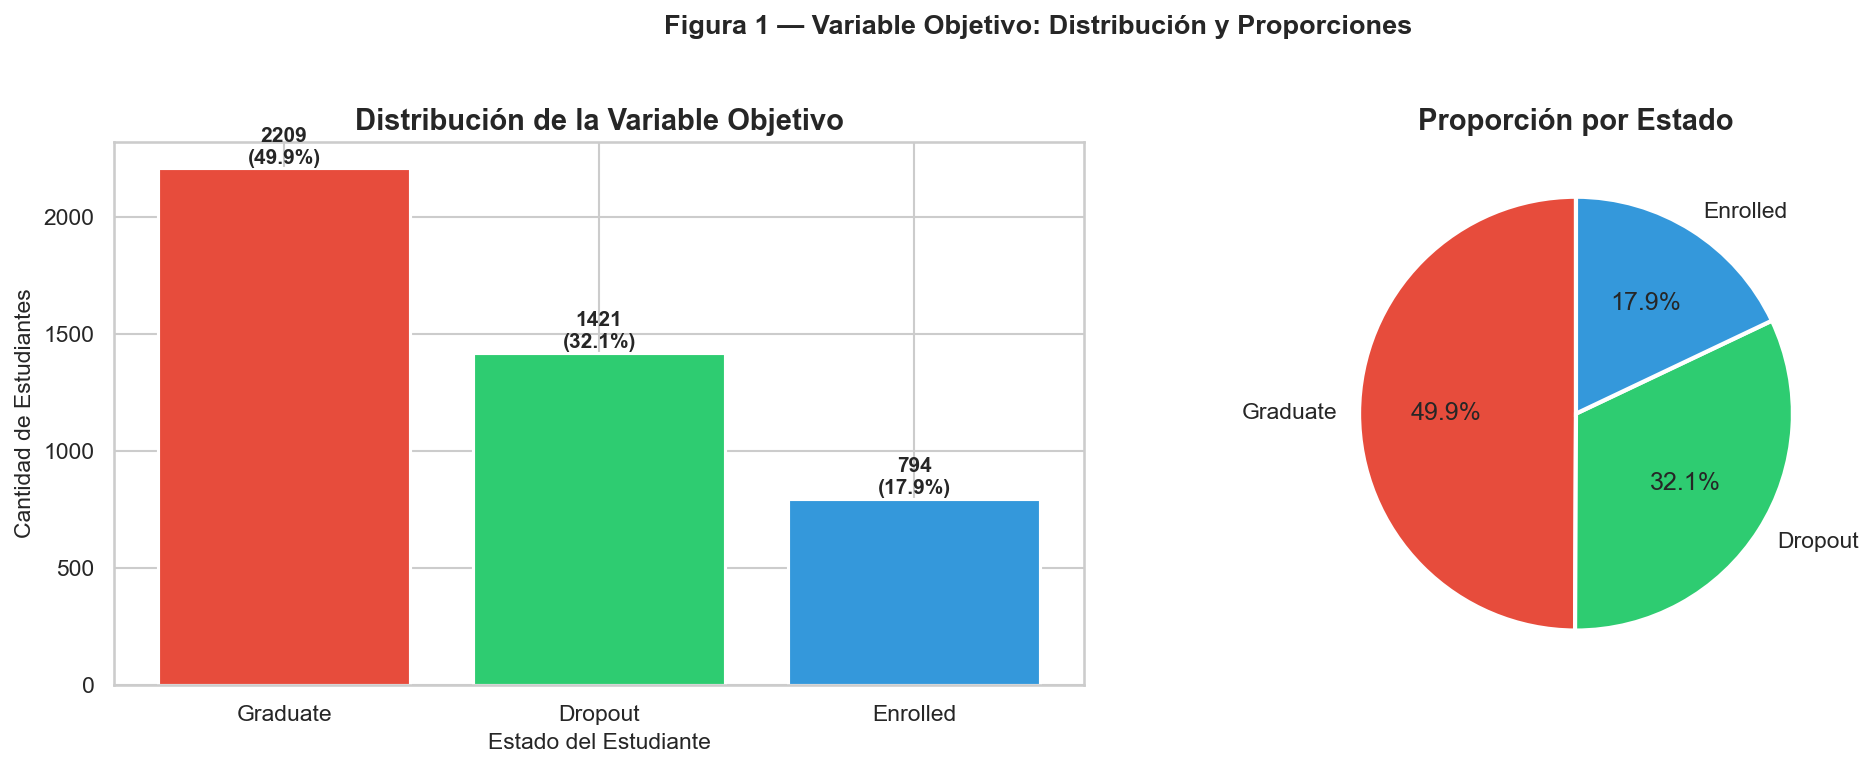


Hallazgo: 32.1% de estudiantes desertan.
Hay desbalance de clases — el Integrante 2 deberá usar class_weight=balanced o SMOTE.


In [6]:
import os
os.makedirs('../data/processed', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = df['Target'].value_counts()
colors = ['#e74c3c', '#2ecc71', '#3498db']

# Barras
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de la Variable Objetivo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Estado del Estudiante', fontsize=11)
axes[0].set_ylabel('Cantidad de Estudiantes', fontsize=11)
for i, (label, v) in enumerate(zip(target_counts.index, target_counts.values)):
    axes[0].text(i, v + 20, f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

# Pie
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporción por Estado', fontsize=14, fontweight='bold')

plt.suptitle('Figura 1 — Variable Objetivo: Distribución y Proporciones',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig1_target_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nHallazgo: {target_counts.get('Dropout', 0)/len(df)*100:.1f}% de estudiantes desertan.")
print('Hay desbalance de clases — el Integrante 2 deberá usar class_weight=balanced o SMOTE.')

## Visualización 2 — Tasa de Deserción por Factores Financieros
Los factores económicos son críticos en la deserción. Analizamos si tener deudas o no estar al día con pagos está correlacionado con abandonar los estudios.

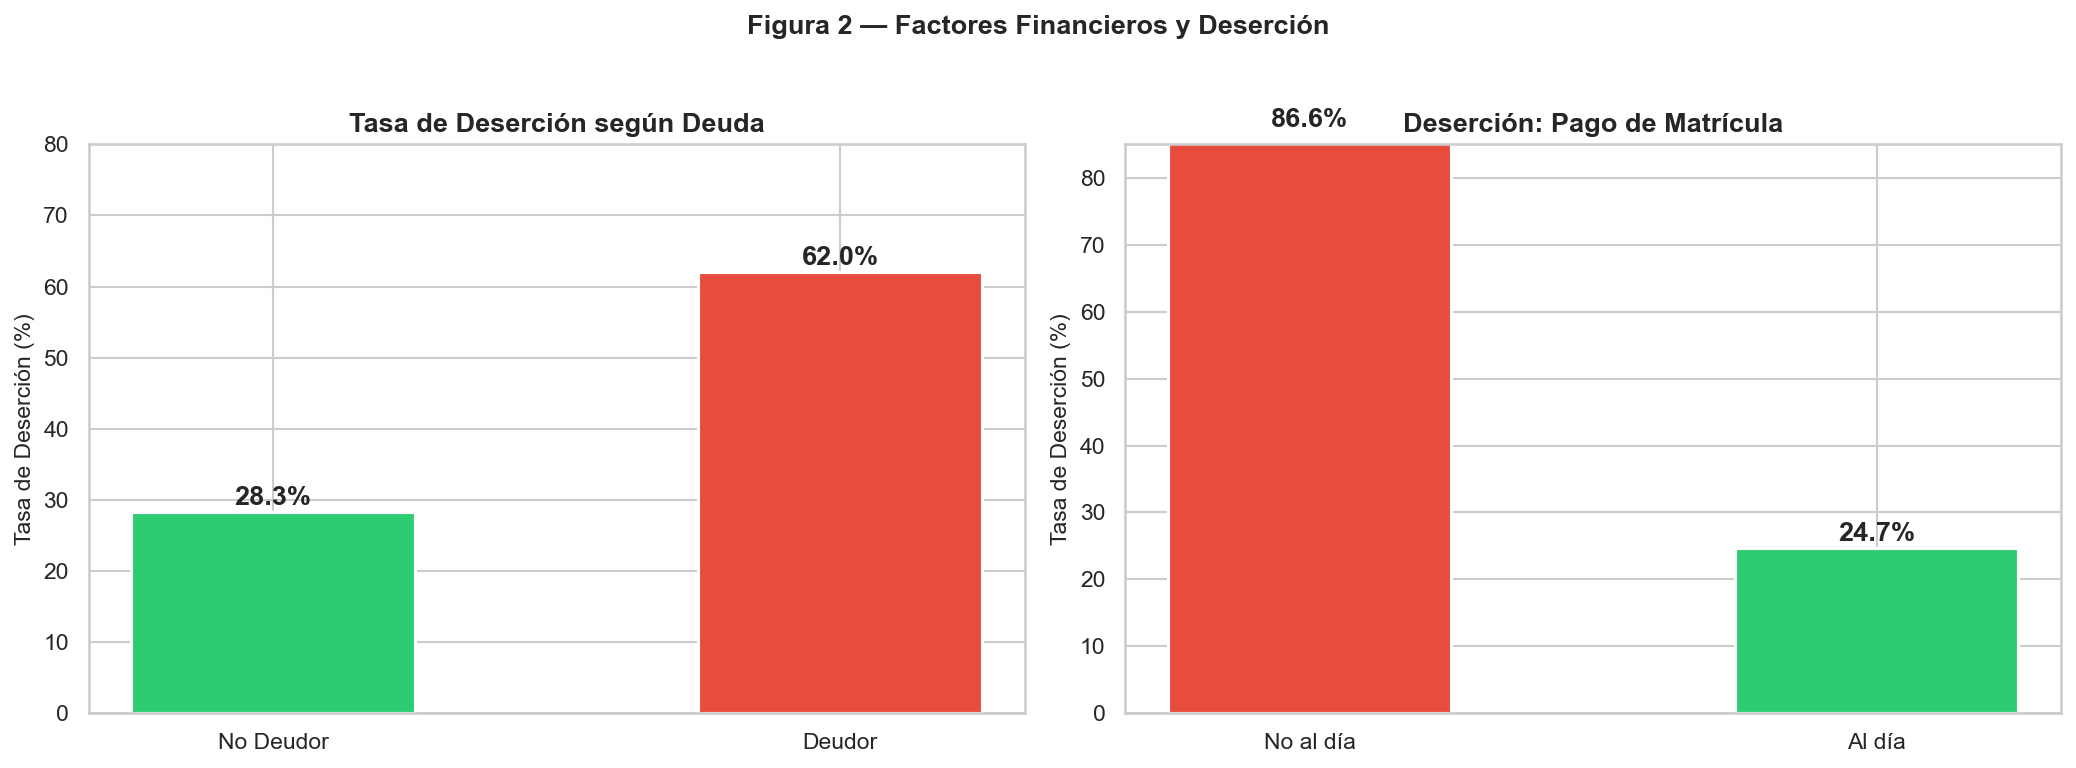

Hallazgo: Los factores financieros tienen impacto significativo en la deserción.


In [7]:
df_binary = df.copy()
df_binary['Dropout'] = (df_binary['Target'] == 'Dropout').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Deudor
debtor_dropout = df_binary.groupby('Debtor')['Dropout'].mean() * 100
bars1 = axes[0].bar(['No Deudor', 'Deudor'], debtor_dropout.values,
                     color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Tasa de Deserción según Deuda', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Tasa de Deserción (%)', fontsize=11)
axes[0].set_ylim(0, 80)
for bar, v in zip(bars1, debtor_dropout.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 1,
                 f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')

# Matrícula al día
tuition_dropout = df_binary.groupby('Tuition fees up to date')['Dropout'].mean() * 100
bars2 = axes[1].bar(['No al día', 'Al día'], tuition_dropout.values,
                     color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('Deserción: Pago de Matrícula', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Tasa de Deserción (%)', fontsize=11)
axes[1].set_ylim(0, 85)
for bar, v in zip(bars2, tuition_dropout.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1,
                 f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('Figura 2 — Factores Financieros y Deserción', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig2_financial_factors.png', dpi=200, bbox_inches='tight')
plt.show()

print('Hallazgo: Los factores financieros tienen impacto significativo en la deserción.')

## Visualización 3 — Rendimiento Académico del Primer Semestre
El primer semestre es el período más crítico: los estudiantes que reprobarán o que abandonarán muestran patrones distintos desde el inicio.

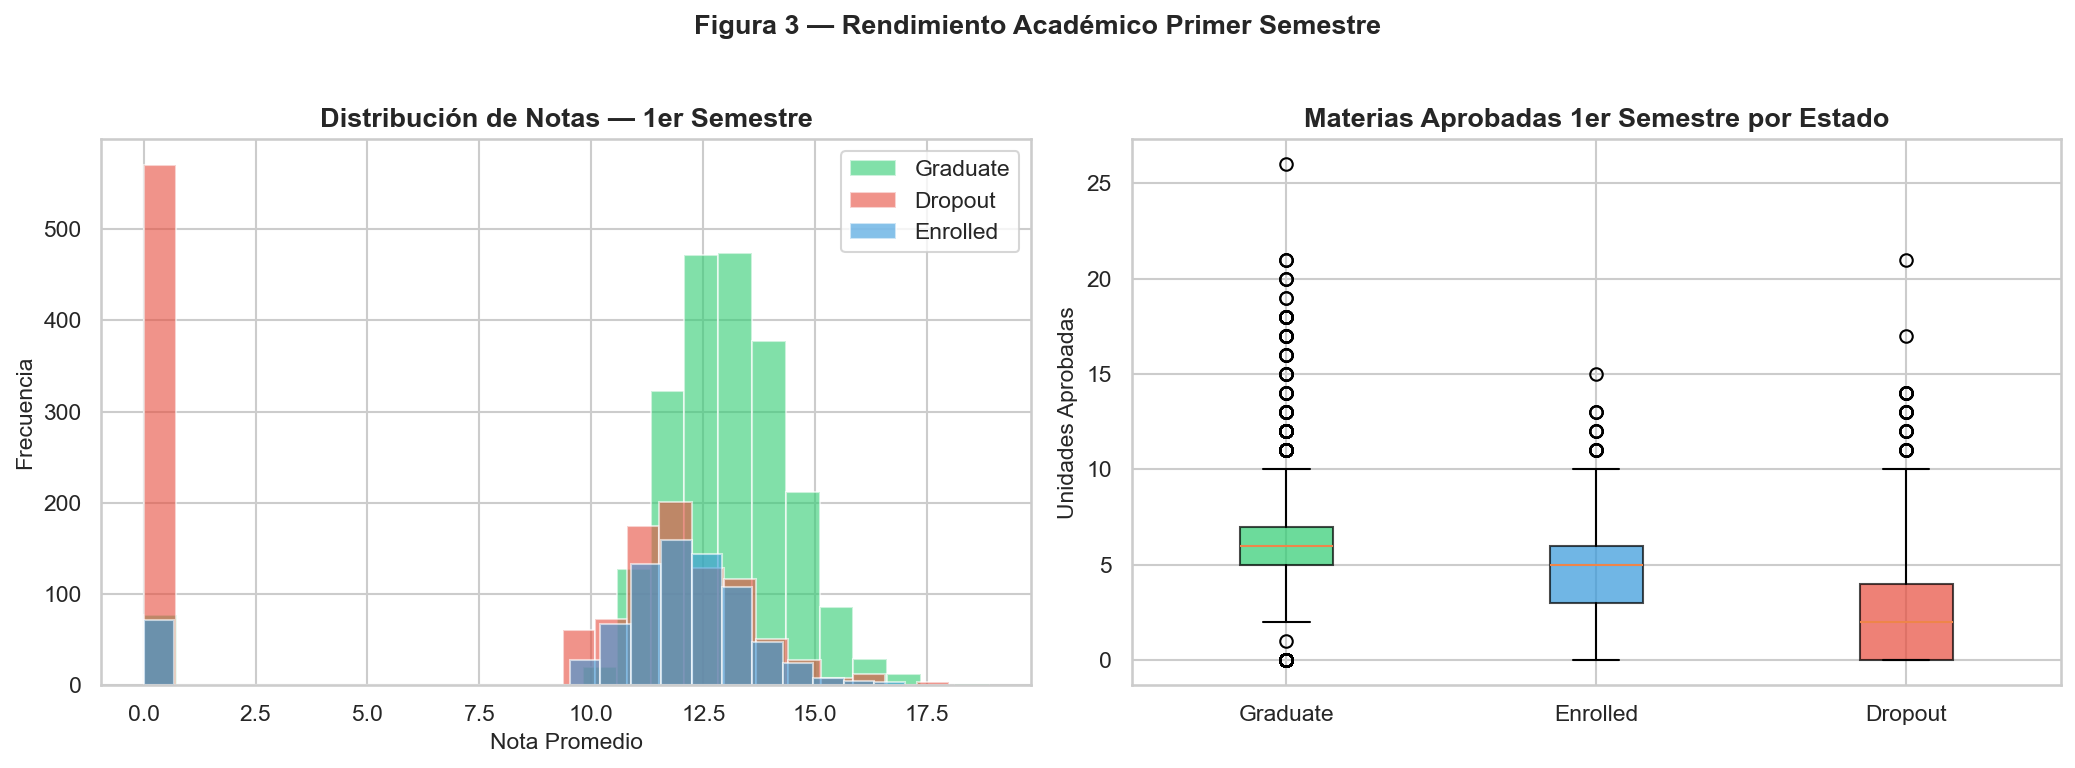

Dropout: nota promedio = 7.26
Graduate: nota promedio = 12.64
Enrolled: nota promedio = 11.13


In [8]:
colores_target = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#3498db'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de notas
for target, color in colores_target.items():
    subset = df[df['Target'] == target]['Curricular units 1st sem (grade)']
    axes[0].hist(subset, alpha=0.6, label=target, bins=25, color=color, edgecolor='white')
axes[0].set_title('Distribución de Notas — 1er Semestre', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nota Promedio', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].legend()

# Materias aprobadas — boxplot
data_boxplot = [df[df['Target'] == t]['Curricular units 1st sem (approved)'].values
                for t in ['Graduate', 'Enrolled', 'Dropout']]
bp = axes[1].boxplot(data_boxplot, patch_artist=True,
                      labels=['Graduate', 'Enrolled', 'Dropout'])
for patch, color in zip(bp['boxes'], ['#2ecc71', '#3498db', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Materias Aprobadas 1er Semestre por Estado', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Unidades Aprobadas', fontsize=11)

plt.suptitle('Figura 3 — Rendimiento Académico Primer Semestre', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig3_academic_performance.png', dpi=200, bbox_inches='tight')
plt.show()

for t in df['Target'].unique():
    media = df[df['Target'] == t]['Curricular units 1st sem (grade)'].mean()
    print(f'{t}: nota promedio = {media:.2f}')

## Visualización 4 — Mapa de Correlaciones
Identificamos qué variables tienen mayor relación lineal con la deserción. Esto orienta la selección de features y valida que el dataset es informativo.

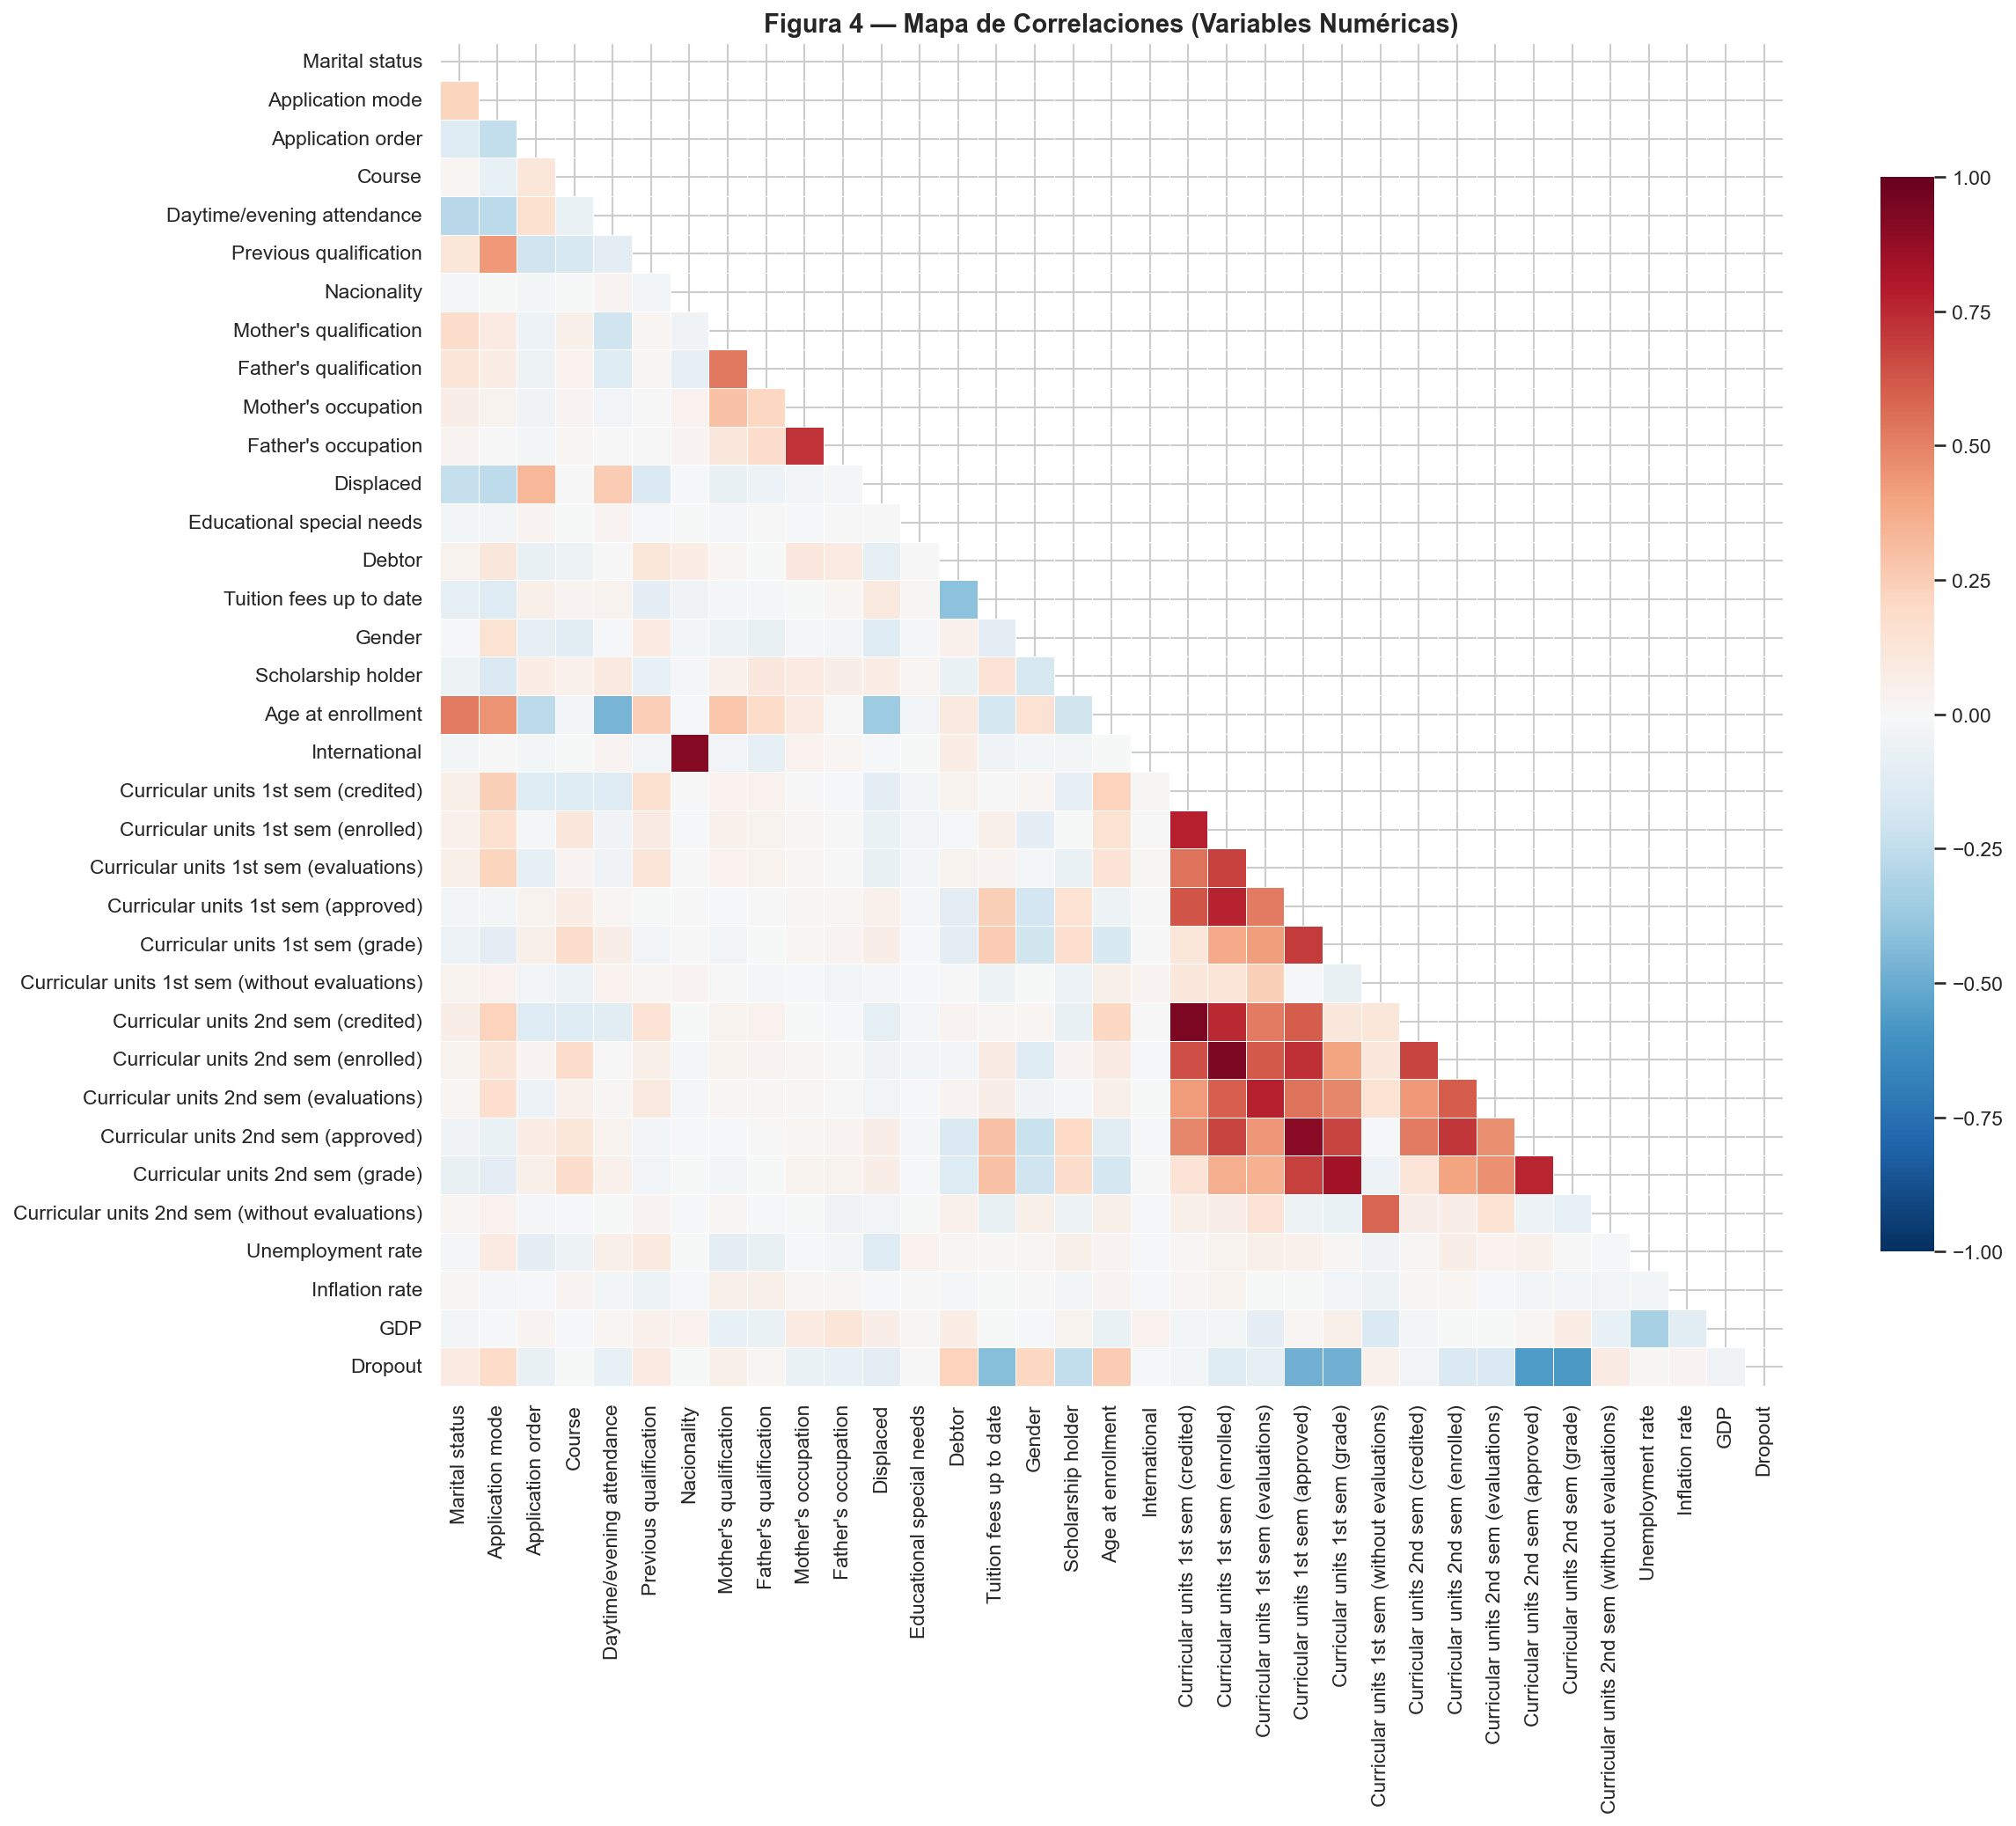

In [9]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_corr = df_binary[numerical_cols + ['Dropout']].copy()
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.3, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Figura 4 — Mapa de Correlaciones (Variables Numéricas)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig4_correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

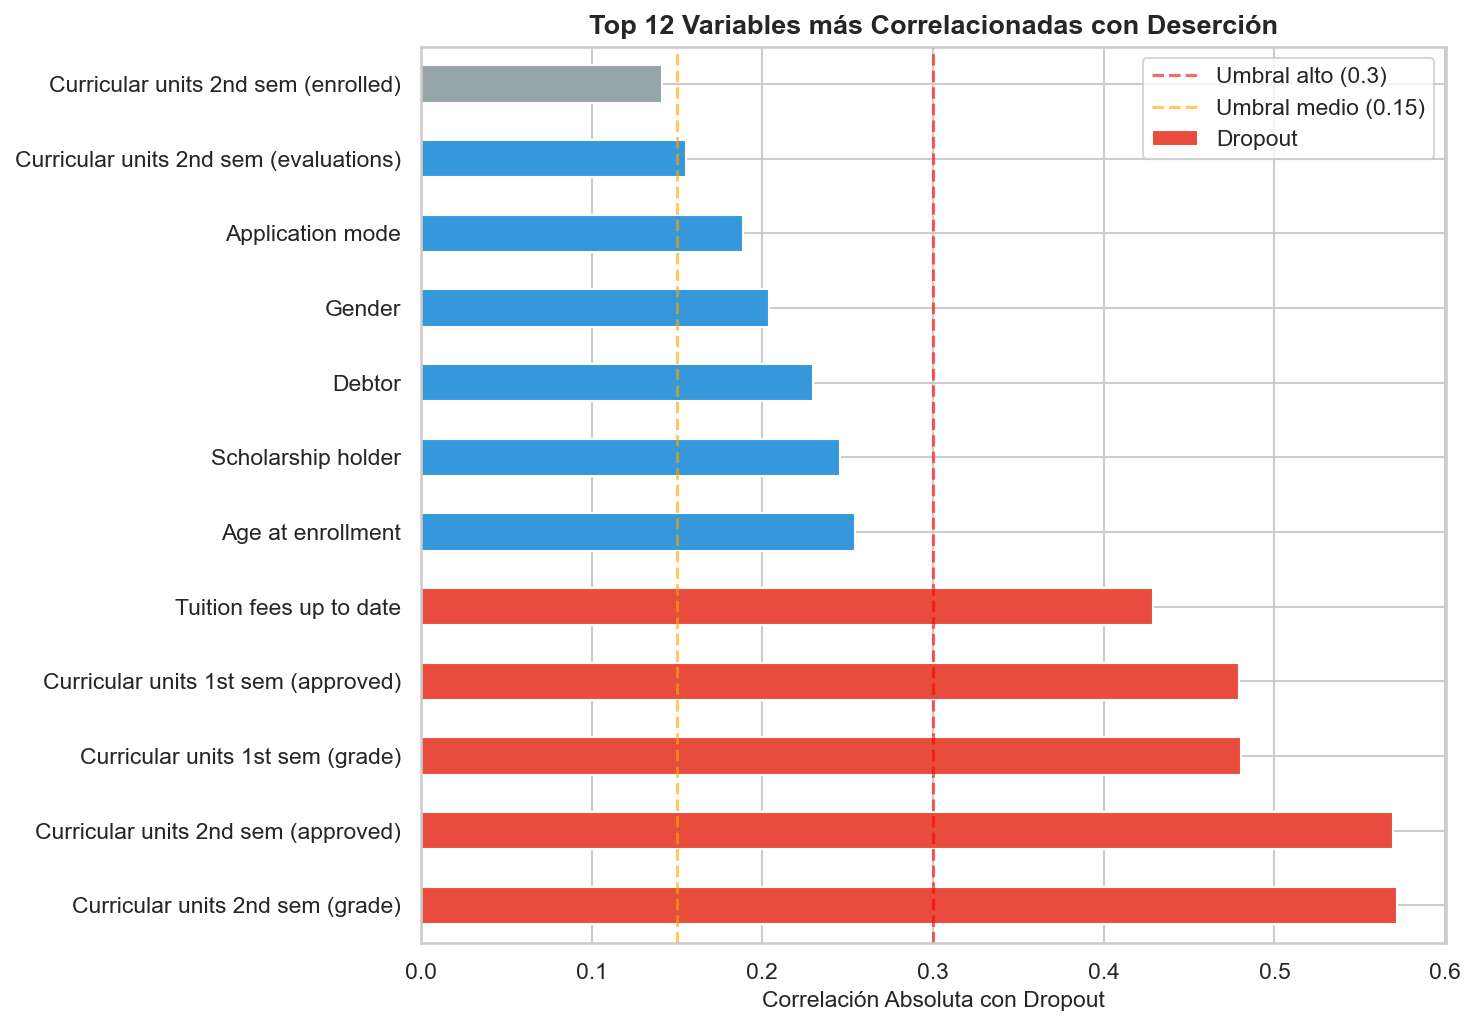


Top 5 features más correlacionadas con deserción:
  Curricular units 2nd sem (grade): 0.572
  Curricular units 2nd sem (approved): 0.570
  Curricular units 1st sem (grade): 0.481
  Curricular units 1st sem (approved): 0.479
  Tuition fees up to date: 0.429


In [10]:
target_corr = corr_matrix['Dropout'].drop('Dropout').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#e74c3c' if v > 0.3 else '#3498db' if v > 0.15 else '#95a5a6'
              for v in target_corr.head(12).values]
target_corr.head(12).plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
ax.set_title('Top 12 Variables más Correlacionadas con Deserción',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación Absoluta con Dropout', fontsize=11)
ax.axvline(x=0.3, color='red', linestyle='--', alpha=0.6, label='Umbral alto (0.3)')
ax.axvline(x=0.15, color='orange', linestyle='--', alpha=0.6, label='Umbral medio (0.15)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig5_top_correlations.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nTop 5 features más correlacionadas con deserción:')
for feat, val in target_corr.head(5).items():
    print(f'  {feat}: {val:.3f}')

## Visualización 5 — Distribución de Edad al Matricularse
Analizamos si la edad al momento de entrar a la universidad influye en la deserción. Estudiantes mayores pueden tener más responsabilidades que dificultan continuar.

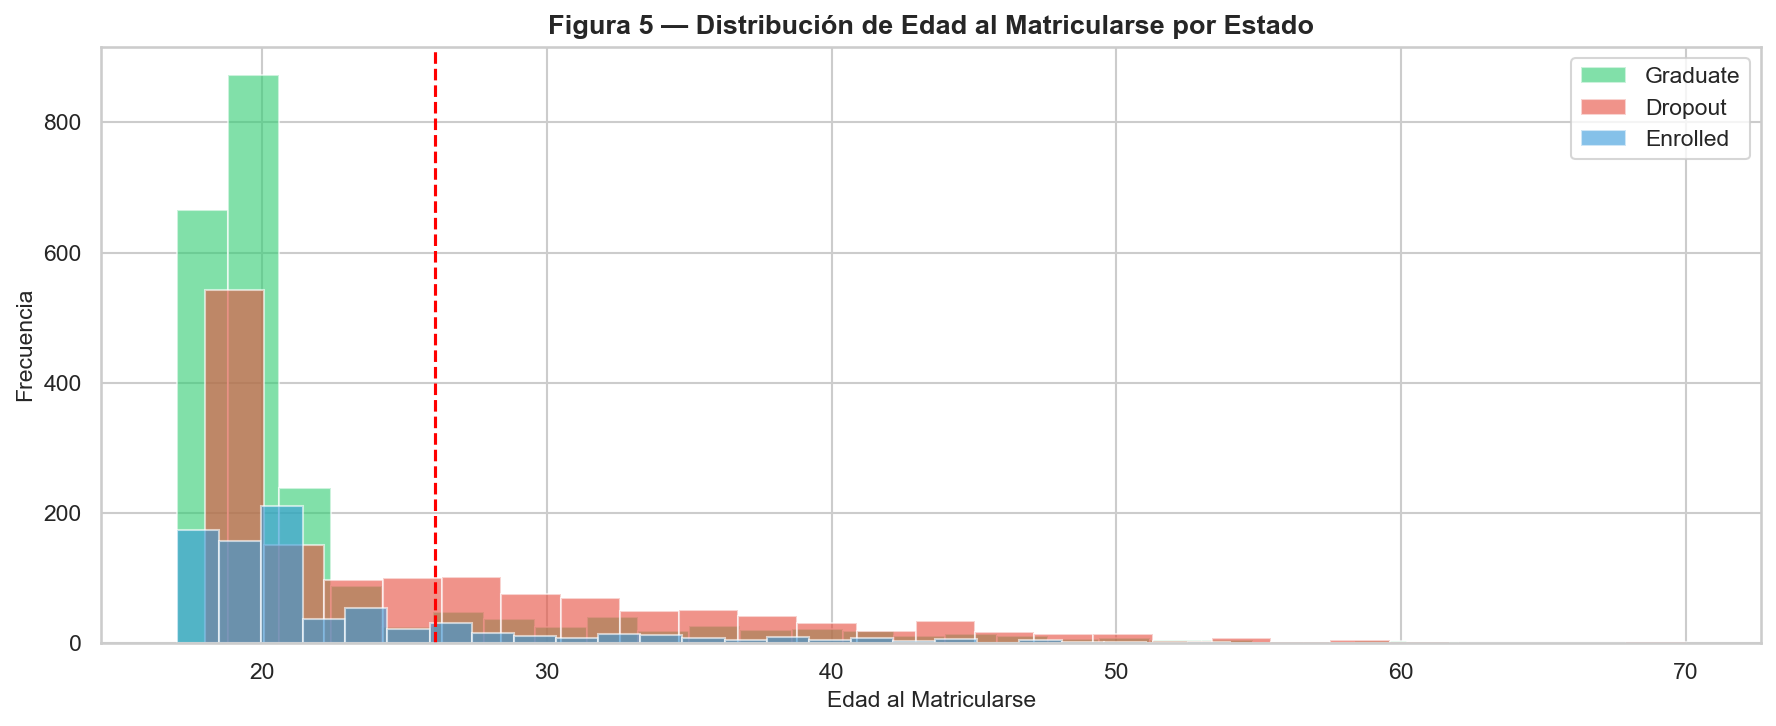

Edad promedio por estado:
Target
Dropout     26.1
Enrolled    22.4
Graduate    21.8
Name: Age at enrollment, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
for target, color in colores_target.items():
    subset = df[df['Target'] == target]['Age at enrollment']
    ax.hist(subset, alpha=0.6, label=target, bins=25, color=color, edgecolor='white')
ax.set_title('Figura 5 — Distribución de Edad al Matricularse por Estado',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Edad al Matricularse', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.legend()
ax.axvline(df[df['Target'] == 'Dropout']['Age at enrollment'].mean(),
           color='red', linestyle='--', label='Media Dropout')
plt.tight_layout()
plt.savefig('../data/processed/fig6_age_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print('Edad promedio por estado:')
print(df.groupby('Target')['Age at enrollment'].mean().round(1))

In [12]:
print('=' * 55)
print('ANÁLISIS DE OUTLIERS — Método IQR')
print('=' * 55)

numerical_cols_clean = df.select_dtypes(include=[np.number]).columns.tolist()

Q1 = df[numerical_cols_clean].quantile(0.25)
Q3 = df[numerical_cols_clean].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numerical_cols_clean] < (Q1 - 1.5 * IQR)) |
            (df[numerical_cols_clean] > (Q3 + 1.5 * IQR))).sum()

outliers_df = outliers[outliers > 0].sort_values(ascending=False)
print(outliers_df.to_string())
print(f'\nEstrategia: Se MANTIENEN los outliers.')
print('Son valores académicos reales (ej: 0 materias aprobadas es válido, no un error).')
print('El modelo LightGBM es robusto a outliers por su naturaleza basada en árboles.')

ANÁLISIS DE OUTLIERS — Método IQR
Scholarship holder                                1099
Curricular units 2nd sem (grade)                   877
Curricular units 1st sem (grade)                   726
Previous qualification                             707
Curricular units 1st sem (credited)                577
Application order                                  541
Curricular units 2nd sem (credited)                530
Tuition fees up to date                            528
Marital status                                     505
Debtor                                             503
Daytime/evening attendance                         483
Age at enrollment                                  441
Curricular units 1st sem (enrolled)                424
Curricular units 2nd sem (enrolled)                369
Curricular units 1st sem (without evaluations)     294
Curricular units 2nd sem (without evaluations)     282
Curricular units 1st sem (approved)                180
Curricular units 1st sem (evalu

**Decisión documentada sobre outliers:**  
Los valores detectados como extremos corresponden a situaciones académicas reales (por ejemplo, cero materias aprobadas en el primer semestre).  
No se eliminarán ni transformarán porque:
- LightGBM es inherentemente robusto a outliers (basado en árboles).
- Alterar estos valores podría distorsionar la información real de abandono.
- Los outliers representan justamente los casos de deserción más severos, que son críticos para el modelo.

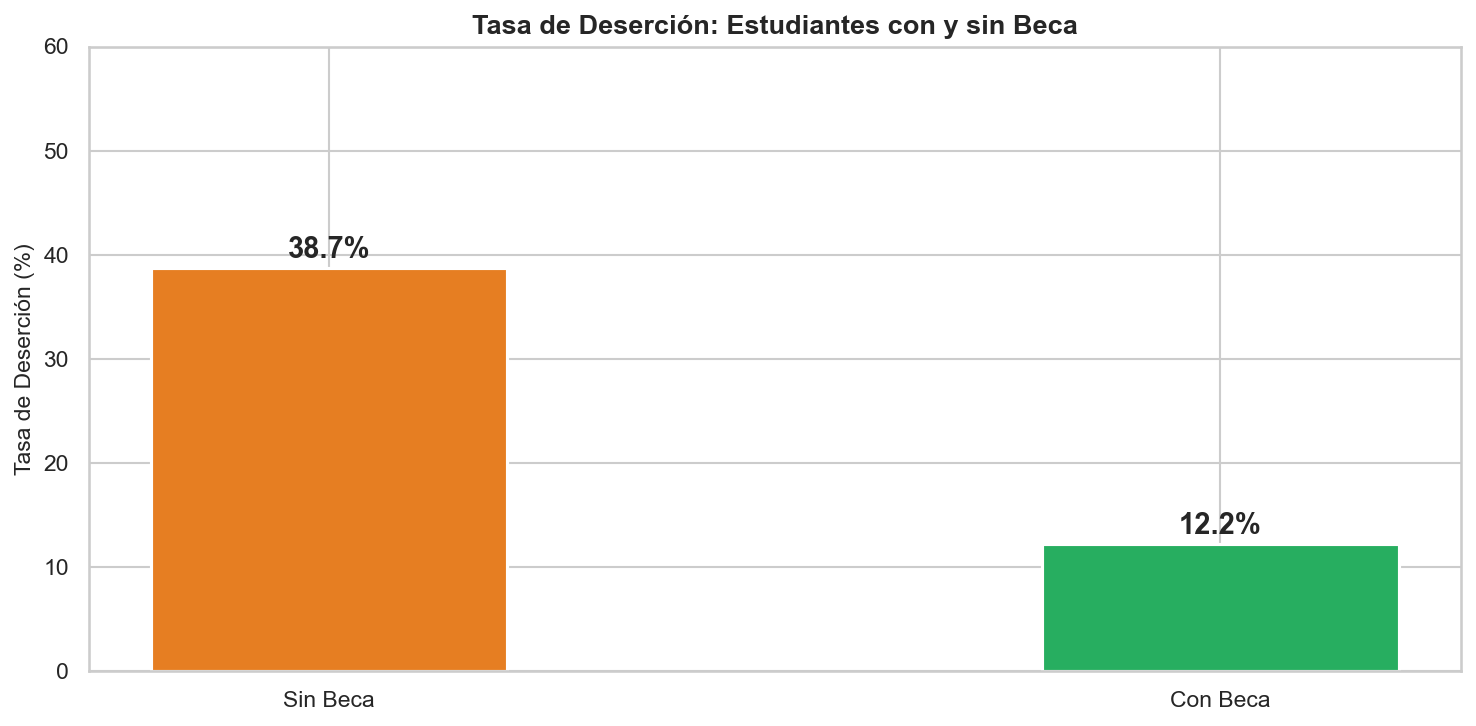

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
scholarship_dropout = df_binary.groupby('Scholarship holder')['Dropout'].mean() * 100
bars = ax.bar(['Sin Beca', 'Con Beca'], scholarship_dropout.values,
               color=['#e67e22', '#27ae60'], edgecolor='white', linewidth=1.5, width=0.4)
ax.set_title('Tasa de Deserción: Estudiantes con y sin Beca', fontsize=13, fontweight='bold')
ax.set_ylabel('Tasa de Deserción (%)', fontsize=11)
ax.set_ylim(0, 60)
for bar, v in zip(bars, scholarship_dropout.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1,
            f'{v:.1f}%', ha='center', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig7_scholarship.png', dpi=200, bbox_inches='tight')
plt.show()

## Resumen de Hallazgos del EDA

| Hallazgo | Detalle |
|----------|----------|
| Desbalance de clases | ~32% deserta, ~50% se gradúa, ~18% sigue matriculado |
| Variables financieras | Deudores y quienes no están al día con pagos tienen tasas de deserción significativamente mayores |
| Rendimiento 1er semestre | Los desertores aprueban menos materias y tienen notas más bajas desde el inicio |
| Edad al matricularse | Estudiantes mayores tienen mayor tendencia a desertar |
| Becas | Los becados tienen menores tasas de deserción |
| Valores nulos | Ninguno — no se requiere imputación |
| Outliers | Mantenidos — valores académicamente válidos |

**Implicaciones para el modelo (Integrante 2):**
- Usar `class_weight='balanced'` en LightGBM o aplicar SMOTE
- Las features de rendimiento del 1er semestre son las más predictivas
- Los factores financieros son el segundo predictor más fuerte
- La edad y la condición de beca complementan el perfil de riesgo

In [14]:
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(df, title='EDA Report - Student Dropout', explorative=True)
    profile.to_file('../data/processed/eda_report.html')
    print('✓ Reporte ydata-profiling generado en data/processed/eda_report.html')
except ImportError:
    print('⚠️ ydata-profiling no está instalado.')
    print('Instálalo con: pip install ydata-profiling')
    print('Luego vuelve a correr esta celda.')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 35/35 [00:00<00:00, 108.76it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Reporte ydata-profiling generado en data/processed/eda_report.html


In [15]:
print('=' * 60)
print('RESUMEN ESTADÍSTICO FINAL — EDA')
print('=' * 60)
print(f'\nDataset shape:        {df.shape}')
print(f'Valores nulos:        {df.isnull().sum().sum()} (ninguno)')
print(f'\nDistribución target:')
for t, v in df['Target'].value_counts().items():
    print(f'  {t}: {v} ({v/len(df)*100:.1f}%)')
print(f'\nTasa de deserción:    {df_binary["Dropout"].mean()*100:.1f}%')
print(f'Top predictor:        {target_corr.index[0]} ({target_corr.iloc[0]:.3f})')
print(f'Figuras generadas:    7 (guardadas en data/processed/)')
print(f'\n✓ EDA completo. Datos listos para preprocesamiento.')

RESUMEN ESTADÍSTICO FINAL — EDA

Dataset shape:        (4424, 35)
Valores nulos:        0 (ninguno)

Distribución target:
  Graduate: 2209 (49.9%)
  Dropout: 1421 (32.1%)
  Enrolled: 794 (17.9%)

Tasa de deserción:    32.1%
Top predictor:        Curricular units 2nd sem (grade) (0.572)
Figuras generadas:    7 (guardadas en data/processed/)

✓ EDA completo. Datos listos para preprocesamiento.
